In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Separate populations

In [ ]:
start_step = 10000
end_step = 60000
steps = end_step - start_step
agents = 1000
steps_vec = Int[]
agents_vec = Int32[]
x_vec = Float64[]
y_vec = Float64[]
threshold = 75

jldopen(filename, "r") do file
    for agent in 1:1000
        for step in step_start:step_end
            g = file[@sprintf("step_%06d", step)]
            x = g["x"][agent]
            y = g["y"][agent]
            dist = sqrt(x^2 + y^2)
            if dist <= threshold
                push!(steps_vec, step)
                push!(agents_vec, agent)
                push!(x_vec, x)
                push!(y_vec, y)
            else
                println()
            end

        end
    end
end

df = DataFrame(
    step = steps_vec,
    agent_id = agents_vec,
    x = x_vec,
    y = y_vec
)


Base.Meta.ParseError: ParseError:
# Error @ c:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl\examples\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:15:19
            g = file[@sprintf("step_%06d", step)]
            x = 
#               
└ ── premature end of input

In [110]:
# --- CONFIGURATION ---
input_file = "fsb_10.0_lambda_2.0.jld2"

start_step = 1  # Equilibrium start (manually inserted)
end_step = 10000   # End of simulation
threshold_distance = 75 # Your threshold
N_agents = 1000    # Fixed number of agents

# --- HELPER ---
function check_agent(file, step, agent_idx, threshold)

    data = file[@sprintf("step_%06d", step)]
    
    x = data["x"][agent_idx]
    y = data["y"][agent_idx]
    
    return sqrt(x^2 + y^2) <= threshold
end

# --- PHASE 1: IDENTIFY VALID AGENTS ---
valid_agents = Int[] # Store indices 1 to 1000

println("Phase 1: Checking dispersion for $N_agents agents from step $start_step to $end_step...")

jldopen(input_file, "r") do file
    for agent_idx in 1:N_agents
        is_valid = true
        
        # Check the entire range for this agent
        for step in start_step:10:end_step
            if !check_agent(file, step, agent_idx, threshold_distance)
                is_valid = false
                break # Stop immediately if one step fails
            end
        end
        
        if is_valid
            push!(valid_agents, agent_idx)
        end
    end
end

println("Phase 1 complete. Found $(length(valid_agents)) valid agents out of $N_agents.")

Phase 1: Checking dispersion for 1000 agents from step 1 to 10000...
Phase 1 complete. Found 614 valid agents out of 1000.


In [111]:
filename = "fsb_10.0_lambda_1.0.jld2"
start_step = 1
end_step = 10000
steps = end_step - start_step
steps_vec = Int[]
agents_vec = Int32[]
x_vec = Float64[]
y_vec = Float64[]

jldopen(filename, "r") do file
    for (idx, agent) in enumerate(valid_agents)
        for step in start_step:10:end_step
            g = file[@sprintf("step_%06d", step)]
            x = g["x"][agent]
            y = g["y"][agent]

            push!(steps_vec, step)
            push!(x_vec, x)
            push!(y_vec, y)
        end
    end
end

df_v10_2_descent = DataFrame(
    step = steps_vec,
    x = x_vec,
    y = y_vec
)


Row,step,x,y
,Int64,Float64,Float64
1,1,0.0,0.0
2,11,0.0,0.0
3,21,0.0,0.0
4,31,0.0,0.0
5,41,0.0,0.0
6,51,0.0,0.0
7,61,0.0,0.0
8,71,0.0,0.0
9,81,0.0,0.0


In [ ]:
function simulate_OU(k, D, dt, T, r0)
    nsteps = Int(T/dt)
    r = zeros(nsteps)
    r[1] = r0

    for i in 2:nsteps
        ξ = randn()
        r[i] = r[i-1] - k * r[i-1] * dt + sqrt(2 * D * dt) * ξ

        # optional: avoid negative distance
        if r[i] < 0
            r[i] = 0.0
        end
    end

    return r
end

In [ ]:
k = 
D =  
dt = 0.01
T = 600
l = 
r0 = l * 2.5
agents = 1000
steps = 60000
distance_vec = zeros(steps, agents)
for agent in 1:agents
    distance_vec[agent, :] = simulate_OU(k, D, dt, T, r0)
end


    


# Histogram

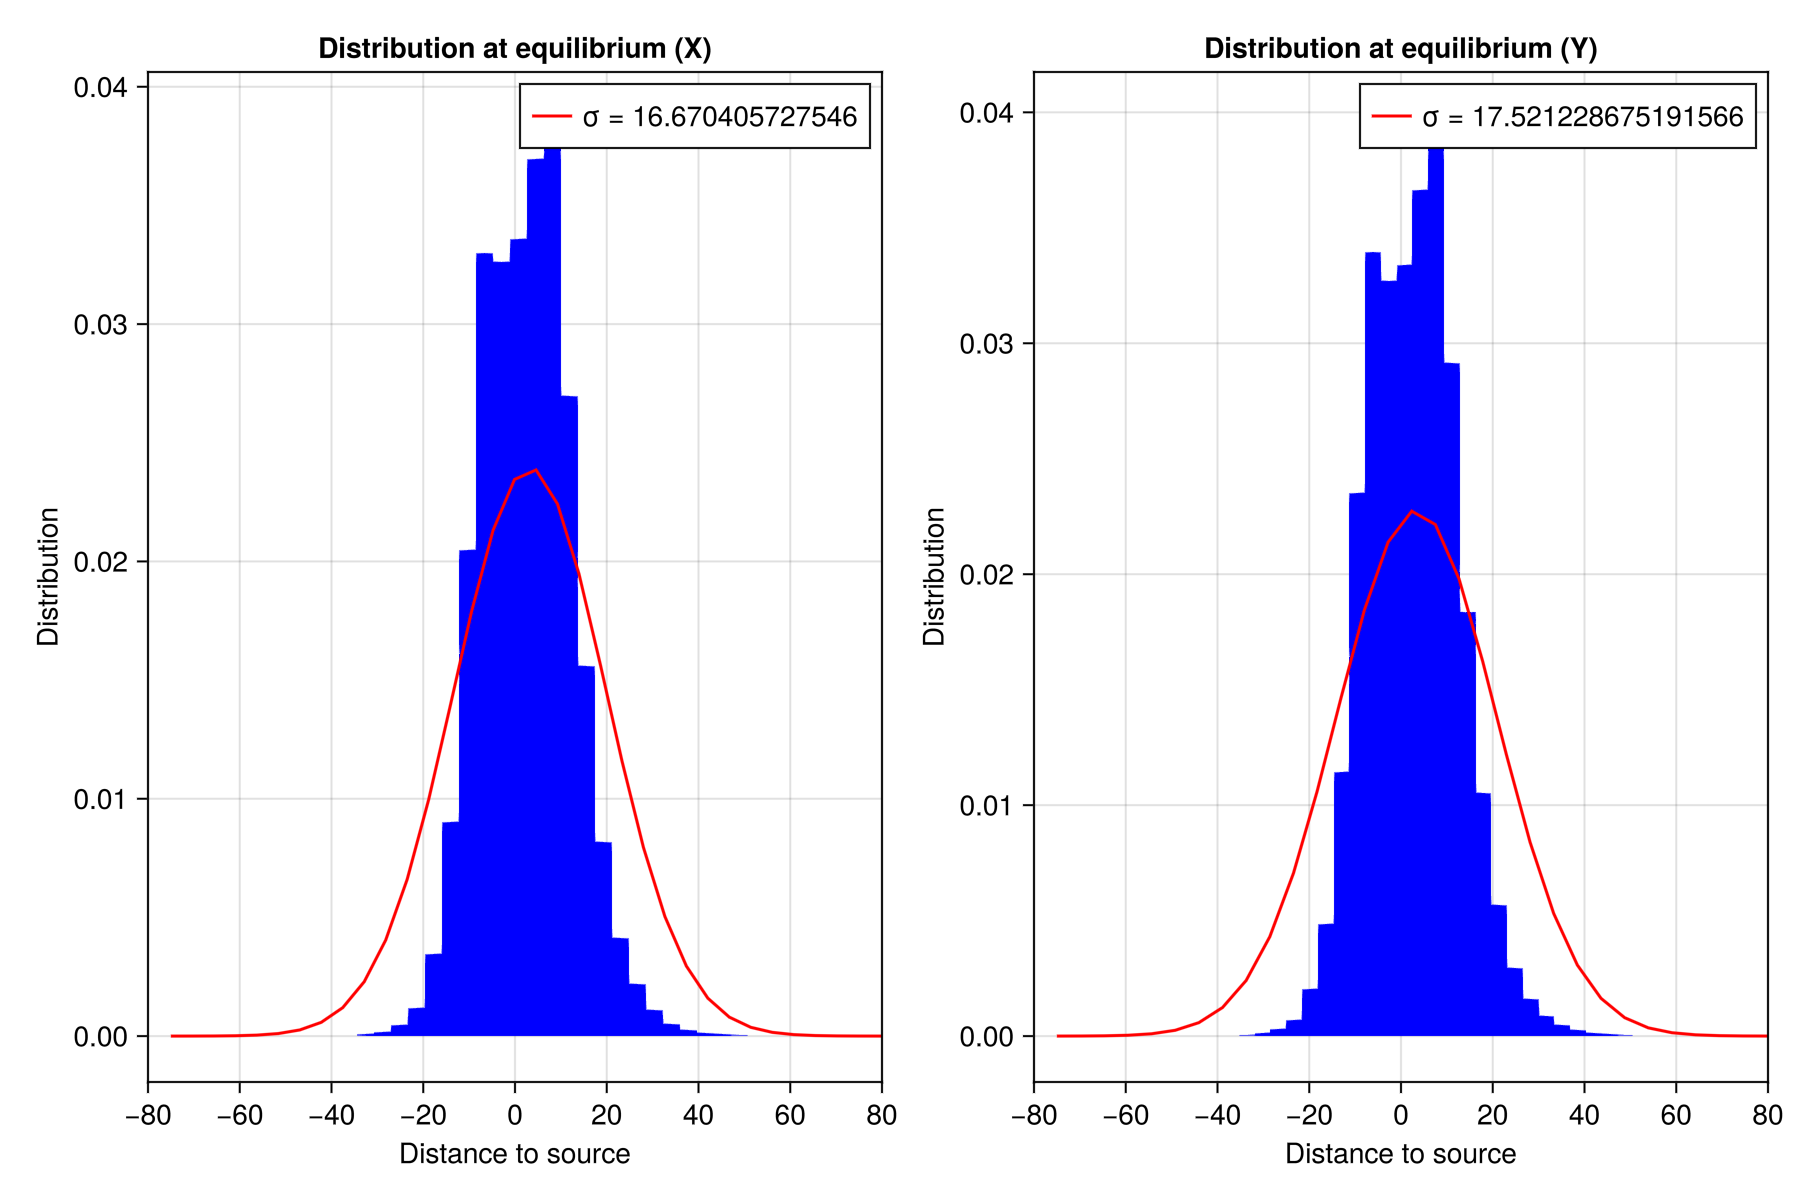

In [108]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1,1], title = "Distribution at equilibrium (X)", xlabel = "Distance to source", ylabel = "Distribution")
ax1 = Axis(fig[1,2], title = "Distribution at equilibrium (Y)", xlabel = "Distance to source", ylabel = "Distribution")

dist = sqrt.((df_v10_1_descent[2:end, 2]).^2 .+ (df_v10_1_descent[2:end, 3]).^2)
hist!(ax,(df_v10_1_descent[2:end, 2]) , normalization = :pdf, bins = 150, color = :blue)
hist!(ax1, (df_v10_1_descent[2:end, 3]), normalization = :pdf, bins = 150, color = :blue)

# Fitting
mu_x = mean(df_v10_1_descent[2:end, 2])
mu_y = mean(df_v10_1_descent[2:end, 3])
sigma_x = std(df_v10_1_descent[2:end, 2])
sigma_y = std(df_v10_1_descent[2:end, 3])
x_fit = range(-75, stop=maximum(df_v10_1_descent[2:end, 2])*1.2, length=125)
y_fit = range(-75, stop=maximum(df_v10_1_descent[2:end, 3])*1.2, length=125)
gaussian_pdf_x = pdf.(Distributions.Normal(mu_x, sigma_x), x_fit)
gaussian_pdf_y = pdf.(Distributions.Normal(mu_y, sigma_y), y_fit)
lines!(ax, x_fit, gaussian_pdf_x, color = :red, label = "σ = $sigma_x")
lines!(ax1, y_fit, gaussian_pdf_y, color = :red, label = "σ = $sigma_y")
axislegend(ax, position = :rt)
axislegend(ax1, position = :rt)
xlims!(ax, -80, 80)
xlims!(ax1, -80, 80)
fig


In [109]:
save("Plots/Fixed_source_model/v10/Subpoblacio_hist_x_y/Lambda_2.png", fig)

# Log lin


In [57]:
test = groups[1]
mean(test[:,3])

3.070607428440761

In [68]:
function linear_fit(x, y)
    """Simple linear regression: y = a + b*x"""
    n = length(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x .* y)
    sum_x2 = sum(x.^2)
    
    slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x^2)
    intercept = (sum_y - slope * sum_x) / n
    
    return slope, intercept
end

linear_fit (generic function with 1 method)

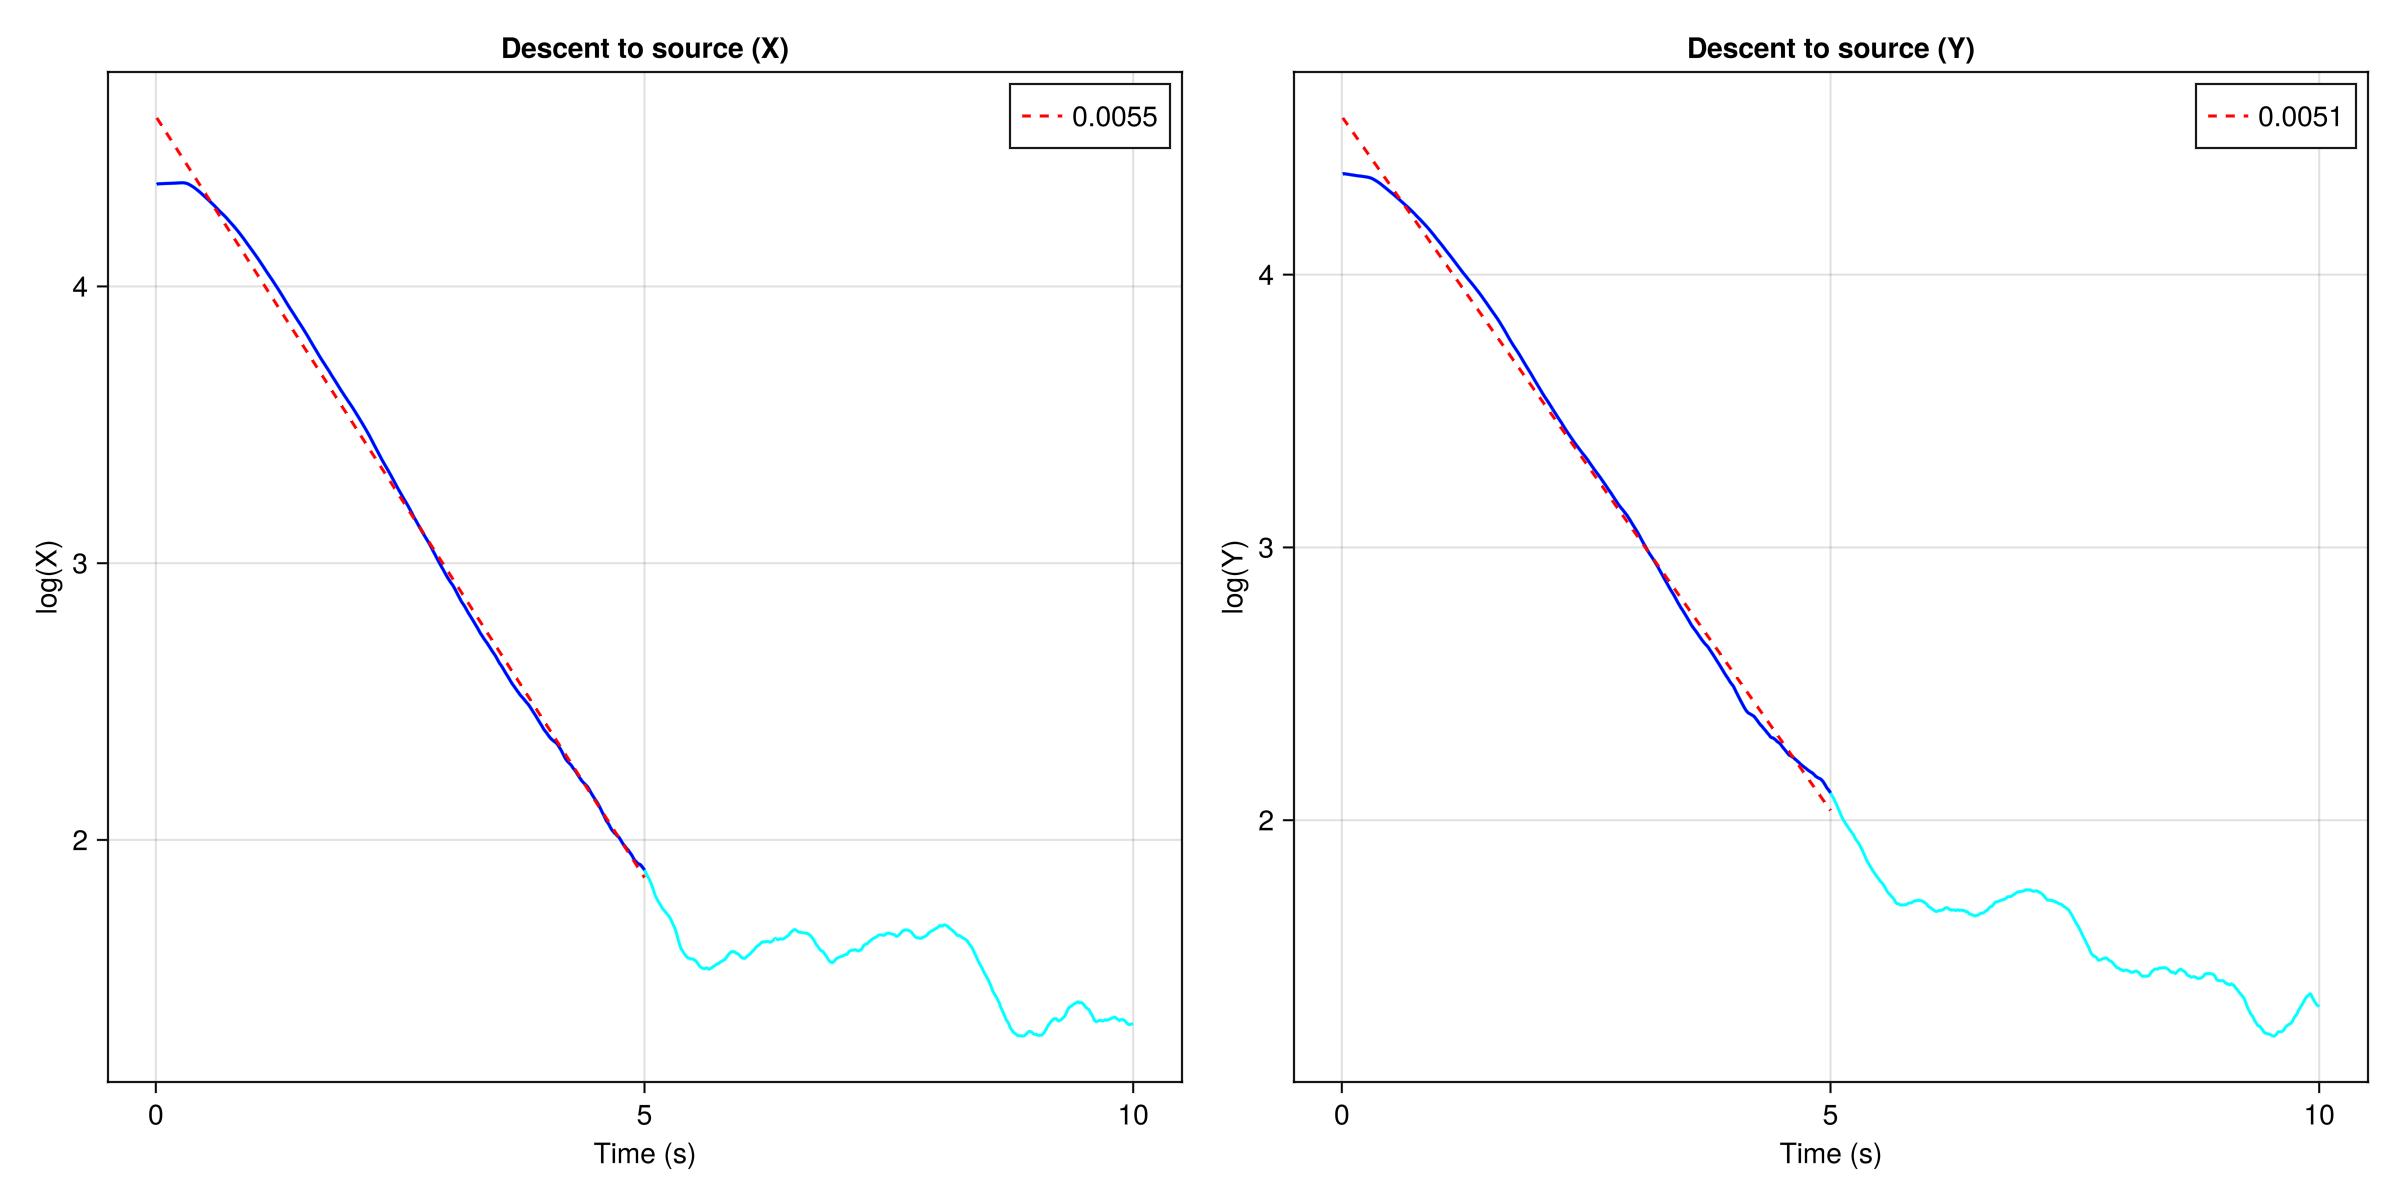

In [122]:
fig2 = Figure(size = (1200, 600))
ax = Axis(fig2[1, 1], title = "Descent to source (X)", xlabel = "Time (s)", ylabel = "log(X)")
ax2 = Axis(fig2[1, 2], title = "Descent to source (Y)", xlabel = "Time (s)", ylabel = "log(Y)")
# df_v10_1[rows, colms]
dist_x = Float64[]
dist_y = Float64[]

groups = groupby(df_v10_2_descent, :step)
for i in 1:length(groups)
    step = groups[i]
    push!(dist_x, mean(step[:, 2]))
    push!(dist_y, mean(step[:, 3]))
end
start_x = 1
end_x = 500
time_vec = 1:30000
lines!(ax, (1:length(groups))*0.01, log.(dist_x), color = :cyan)
lines!(ax, (time_vec[start_x:end_x])*0.01, log.(dist_x[start_x:end_x]), color = :blue)
lines!(ax2, (1:length(groups))*0.01, log.(dist_y), color = :cyan)
lines!(ax2, (time_vec[start_x:end_x])*0.01, log.(dist_y[start_x:end_x]), color = :blue)

# Fitting
slope_x, intercept_x = linear_fit(time_vec[start_x:end_x], log.(dist_x[start_x:end_x]))
slope_y, intercept_y = linear_fit(time_vec[start_x:end_x], log.(dist_y[start_x:end_x]))

fitted_line_x = [intercept_x + slope_x * t for t in time_vec]
fitted_line_y = [intercept_y + slope_y * t for t in time_vec]
k_x = - slope_x
k_y = - slope_y

lines!(ax, time_vec[start_x:end_x]*0.01, fitted_line_x[start_x:end_x], label = "$(round(k_x, digits = 4))", color = :red, linestyle = :dash)
lines!(ax2, time_vec[start_x:end_x]*0.01, fitted_line_y[start_x:end_x], label = "$(round(k_y, digits = 4))", color = :red, linestyle = :dash)
axislegend(ax, position = :rt)
axislegend(ax2, position = :rt)

fig2

In [120]:
save("Plots/Fixed_source_model/v10/Subpopulations_log_lin_x_y/Lambda_2.png", fig2)

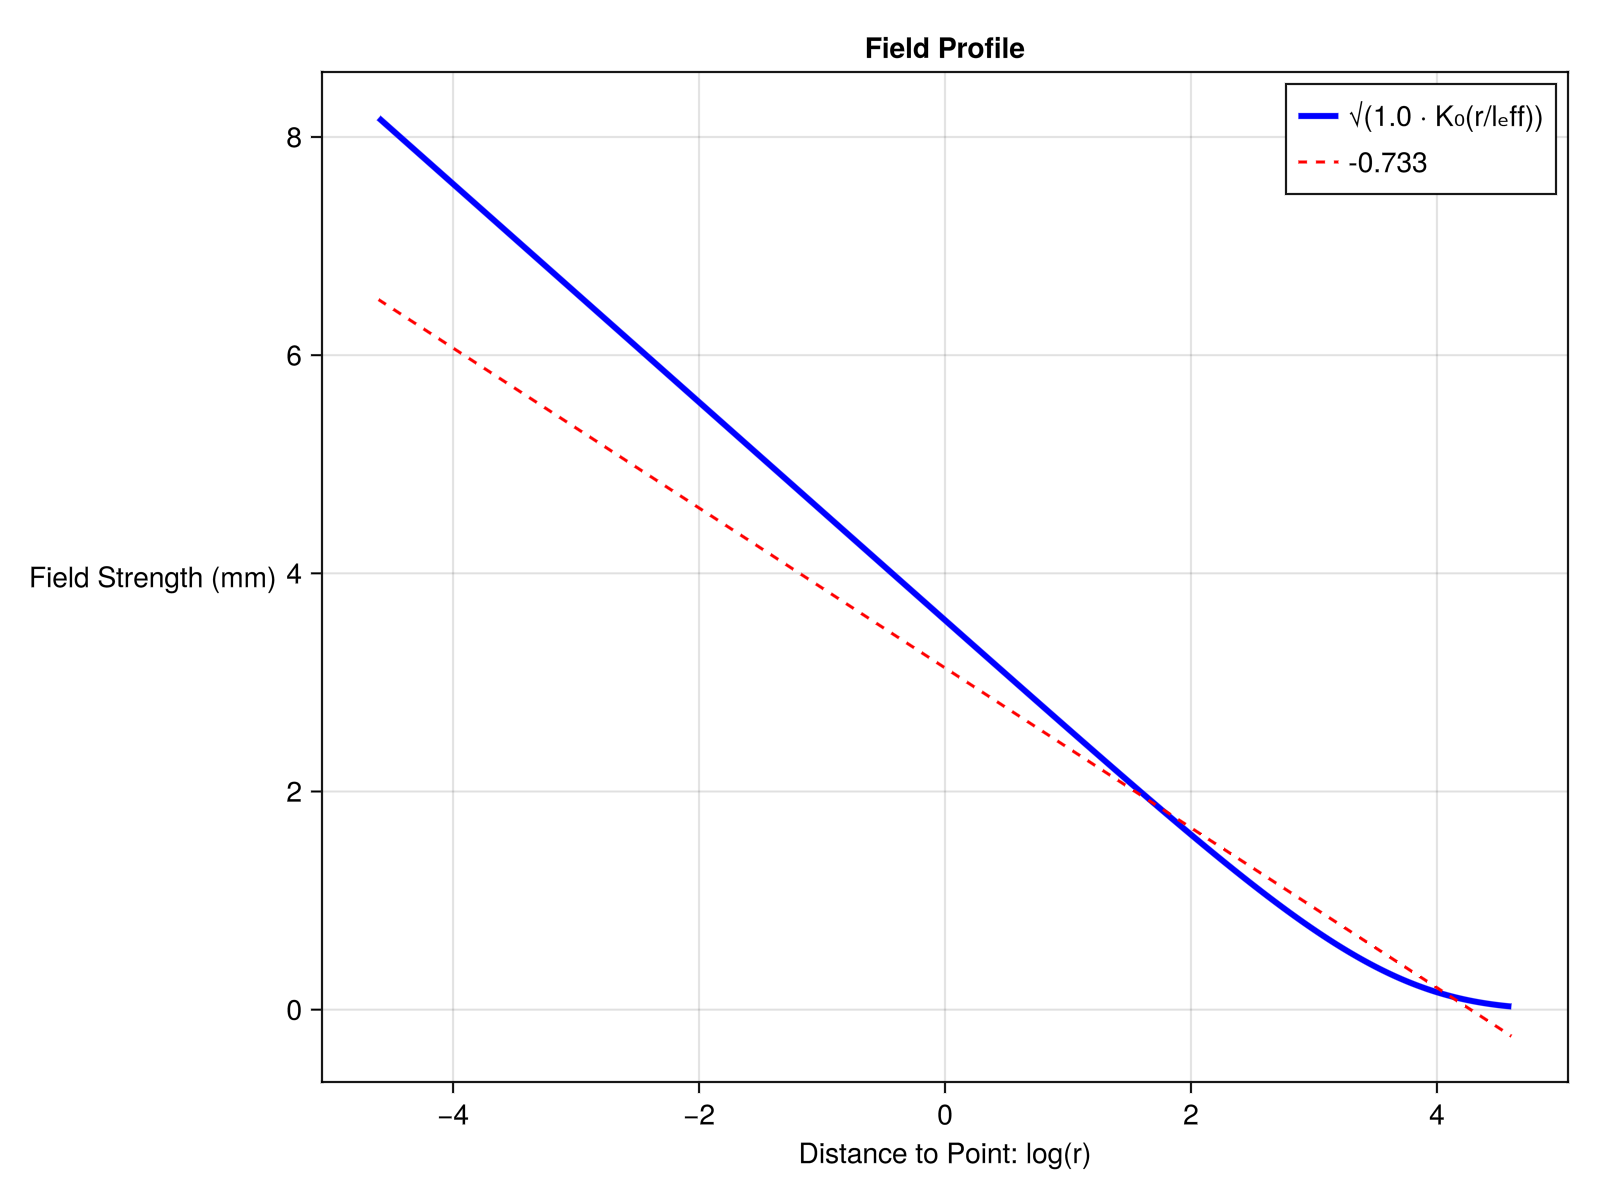

In [84]:
# --- 1. CONFIGURATION ---
mm_factor = 1.0
Dc = 10.0
delta = 0.01
ll = sqrt(Dc/delta)        # Effective length scale (l_eff)
r_max = 100.0         # Maximum distance to plot (e.g., 5 * ll)

# Generate distance vector (x-axis)
# Start at 0.01 to avoid the singularity at r=0 (K0(0) -> Inf)
r = LinRange(0.01, r_max, 500) 

# --- 2. CALCULATION ---
# Calculate m = 1.0 * K0(r / ll)
# besselk(0, x) is the modified Bessel function of the second kind, order 0
m_vals = mm_factor .* besselk.(0, r ./ ll)

# Calculate the square root
# Ensure we don't take sqrt of negative numbers (K0 is positive for r>0)
sqrt_m_vals = sqrt.(m_vals)

# --- 3. PLOTTING ---
fig = Figure(size = (800, 600), fontsize = 14)
ax = Axis(fig[1, 1], 
          title = "Field Profile",
          xlabel = "Distance to Point: log(r)",
          ylabel = "Field Strength (mm)",
          ylabelrotation = 0)

# Plot the line
lines!(ax, log.(r), m_vals, 
       color = :blue, 
       linewidth = 3, 
       label = "√(1.0 · K₀(r/lₑff))")

slope_x, intercept_x = linear_fit(log.(r), m_vals)
fitted_line_x = [intercept_x + slope_x * t for t in log.(r)]
lines!(ax, log.(r), fitted_line_x, label = "$(round(slope_x, digits = 4))", color = :red, linestyle = :dash)



# Add legend
axislegend(ax, position = :rt)

# Display the figure
fig